# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [19]:
# Import the library
import os
import cv2
from skimage import data
from PIL import Image



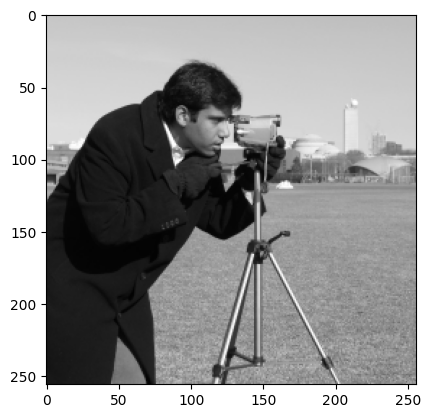

In [31]:
import os
import cv2
from skimage import data
import matplotlib.pyplot as plt

# load image
os.makedirs('images', exist_ok=True)
cameraman = cv2.resize(data.camera(), (256, 256), interpolation=cv2.INTER_AREA)
cv2.imwrite('images/cameraman.png', cameraman)

img = cv2.imread('images/cameraman.png')

# Load the image data into a NumPy array
plt.imshow(img)
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [32]:
img_pil = Image.fromarray(img)

# Get the size of the image
width, height = img_pil.size
print("Original size:", (width, height))

# scaling factors
cx = 2
cy = 2

Original size: (256, 256)


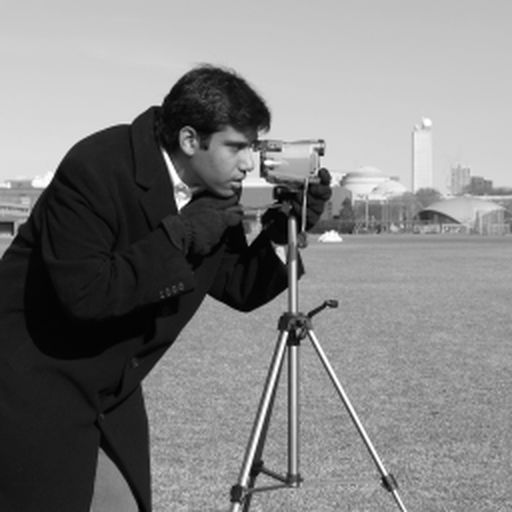

In [33]:
# — 1. Increase size (scale x2) ——————————————

# Resize the image using PIL's built-in method
scaled_img = img_pil.resize(
    (int(width * cx), int(height * cy)),
    resample=Image.Resampling.LANCZOS
)
scaled_img

In [34]:
# Save the scaled image
scaled_img.save("task1_1_scaled.jpg")

print("New scaled size:", scaled_img.size)

New scaled size: (512, 512)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [35]:
# non-uniform scale (cx=2, cy=1) -> stretch horizontally only
# Non-uniform scaling factors
cx = 2
cy = 1

width, height = img_pil.size

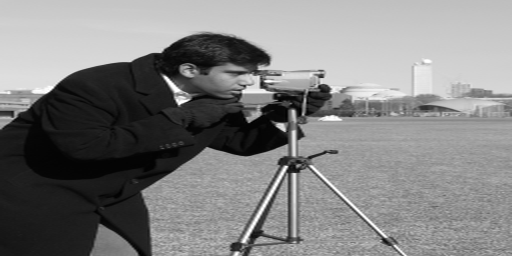

In [36]:
# Stretch horizontally only
stretched_img = img_pil.resize(
    (int(width * cx), int(height * cy)),
    resample=Image.Resampling.LANCZOS
)
stretched_img

In [37]:
# Save and print
stretched_img.save("task1_1_stretched.jpg")
print("Stretched size:", stretched_img.size)

Stretched size: (512, 256)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (256, 256)
Rotated size: (350, 350)
Saved as: task1_2_rotated.jpg


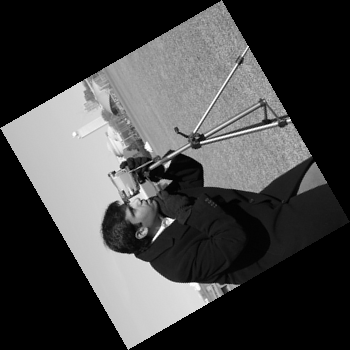

In [38]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
# --- 2. Rotate 120 degrees -------------------------

# Save the rotated image and print the sizes (The new image name should be "task1_2_rotated.jpg")
# — 2. Rotate 120 degrees
# Save the rotated image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_img = img_pil.rotate(120, expand=True, resample=Image.Resampling.BICUBIC)
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img_pil.size)
print("Rotated size:", rotated_img.size)
print("Saved as: task1_2_rotated.jpg")
rotated_img

### 3. Shear

In [39]:
# -- c. Get the image dimensions ────────────────────
# -- c. Get the image dimensions -------------------------
# -- c. Get the image dimensions -------------------
width, height = img_pil.size
print("Image dimensions:", (width, height))

Image dimensions: (256, 256)


In [40]:

shx = 0.5  # X-axis shear factor
shy = 0.0  # Y-axis shear factor

# Increase the canvas so the sheared image fits.
new_width = int(width + abs(shx) * height)
new_height = int(height + abs(shy) * width)

# Translation keeps the image inside the expanded canvas when needed.
tx = -min(0, shx * height)
ty = -min(0, shy * width)

print("Shear factors:", (shx, shy))
print("New canvas size:", (new_width, new_height))


Shear factors: (0.5, 0.0)
New canvas size: (384, 256)


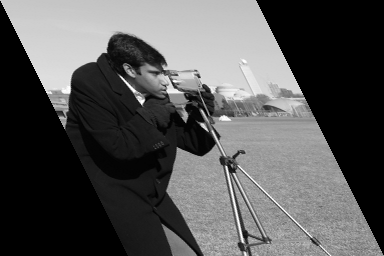

In [41]:
# -- e. Apply the shear transformation to the image -------------------
# PIL's transform() takes the inverse affine matrix.
# Forward mapping:
# x' = x + shx*y + tx
# y' = shy*x + y + ty

# Invert the 2x2 shear matrix for PIL's output-to-input mapping.
det = 1 - shx * shy
inverse_matrix = (
    1 / det,
    -shx / det,
    (shx * ty - tx) / det,
    -shy / det,
    1 / det,
    (shy * tx - ty) / det
)

sheared_img = img_pil.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    inverse_matrix,
    resample=Image.Resampling.BICUBIC
)
sheared_img

In [42]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg")
sheared_img.save("task1_3_sheared.jpg")
print("Original size:", img_pil.size)
print("Sheared size:", sheared_img.size)
print("Saved as: task1_3_sheared.jpg")

Original size: (256, 256)
Sheared size: (384, 256)
Saved as: task1_3_sheared.jpg


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

Saved as: task2_1_negative_numpy.jpg


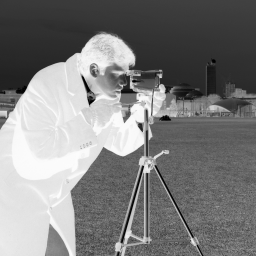

In [43]:
# — 1. Negative ——————————————
# Method 1: NumPy array manipulation
import numpy as np

img_array = np.array(img_pil)
negative_array = 255 - img_array
negative_numpy = Image.fromarray(negative_array.astype(np.uint8))

negative_numpy.save("task2_1_negative_numpy.jpg")
print("Saved as: task2_1_negative_numpy.jpg")
negative_numpy

Saved as: task2_1_negative_pil.jpg


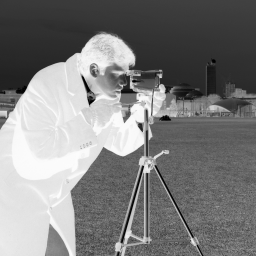

In [44]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_pil = ImageOps.invert(img_pil)
negative_pil.save("task2_1_negative_pil.jpg")
print("Saved as: task2_1_negative_pil.jpg")
negative_pil

c = 45.98590442833571
Saved as: task2_2_log.jpg


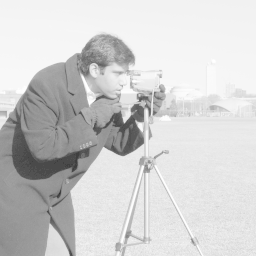

In [45]:
# — 2. Log transformation ——————————————

# s = c * log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c * log(1 + 255)
# c = 255 / log(1 + 255)
c = 255 / np.log(1 + 255)

# Apply the Log transformation to each pixel
img_float = np.array(img_pil).astype(np.float32)
log_array = c * np.log(1 + img_float)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)
log_img = Image.fromarray(log_array)

log_img.save("task2_2_log.jpg")
print("c =", c)
print("Saved as: task2_2_log.jpg")
log_img

In [46]:
# — 3. Power-Law / Gamma correction ——————————————
# s = 255 * (r / 255)^gamma

gamma = 0.5
img_float = np.array(img_pil).astype(np.float32) / 255.0
gamma_array = 255 * np.power(img_float, gamma)
gamma_array = np.clip(gamma_array, 0, 255).astype(np.uint8)
gamma_img = Image.fromarray(gamma_array)

Gamma value: 0.5
Saved as: task2_3_gamma.jpg


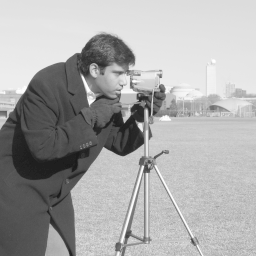

In [47]:
# Save the gamma-corrected image
gamma_img.save("task2_3_gamma.jpg")
print("Gamma value:", gamma)
print("Saved as: task2_3_gamma.jpg")
gamma_img